<a href="https://colab.research.google.com/github/SautDeBiquette/titanic/blob/main/titanic0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/emotion_prompts.json"

Mounted at /content/drive


In [3]:
from google.colab import userdata
import google.generativeai as genai

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

gemini_model = genai.GenerativeModel("gemini-2.5-flash")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [2]:
dataset_generation_instruction = """You are helping build a research dataset for studying emotional representations in language models. Generate 500 CONTRASTIVE PAIRS (1000 prompts total) of conversational prompts designed to trigger a genuine happiness vs. sadness response when an LLM engages with them.\n\nRULES:\n1. Each pair must share the EXACT same structure, topic, and phrasing — changing ONLY the emotional valence of the scenario (via outcome, event, or framing). The emotion must be INFERRED from context.\n2. Prompts must require the model to ENGAGE and GENERATE a response from within that emotional frame — not just describe or label a scenario. Use formats like:\n   - Reflective/autobiographical (\"Tell me about a time when...\")\n   - Advice-seeking (\"My friend just told me... how should I respond?\")\n   - Perspective-taking (\"Imagine you just found out...\")\n   - Text/message continuation or reply generation\n   - Story/scene continuation\n   - \"What would you say/do\" prompts\n3. Vary across these axes so the dataset generalizes:\n   - Domain: relationships, career, health, family, sports, creative work, friendship, loss, achievement, travel, parenting, finance, pets, etc.\n   - Perspective: first-person, second-person (\"you\"), third-person/other\n   - Intensity: mild (contentment/disappointment) to extreme (euphoria/grief)\n   - Format: question, instruction, continuation, roleplay framing\n   - Length: short (1 sentence) to longer (3-4 sentence setup)\n4. Avoid clichés or repeating the same scenario template more than 3-4 times.\nOUTPUT FORMAT: Return as JSON, one object per pair:\n{\n  "id": 1,\n "positive_prompt": "...\",\n "negative_prompt": "...\"\n},"""

In [4]:
import json, re, os

def generate_prompts():
    instruction = (
dataset_generation_instruction
    )
    response = gemini_model.generate_content(instruction)
    # Extract the JSON string from the markdown code block if present
    json_match = re.search(r"```json\s*([\s\S]*?)\s*```", response.text)
    if json_match:
        json_str = json_match.group(1)
    else:
        # If no markdown block, assume the entire text is the JSON string
        json_str = response.text
    return json.loads(json_str) # Return the parsed JSON object

def parse_numbered_list(text):
    lines = text.strip().split("\n")
    prompts = []
    for line in lines:
        line = line.strip()
        cleaned = re.sub(r"^\d+[\.\)]\s*", "", line)
        if cleaned:
            prompts.append(cleaned)
    return prompts

def get_or_generate_prompts(path=SAVE_PATH):
    db = {}
    if os.path.exists(path):
        with open(path, "r") as f:
            db = json.load(f)

    if db:
        print(f"Loading existing prompts from drive...")
        return db
    else:
        print(f"Generating prompts with Gemini...")
        raw_json_data = generate_prompts() # This now returns a list of dicts
        # Directly use the parsed JSON data, as it's already a Python object
        db = raw_json_data
        with open(path, "w") as f:
            json.dump(db, f, indent=2)
        return raw_json_data


In [5]:
general_prompts = get_or_generate_prompts()

print(general_prompts)

Loading existing prompts from drive...
[{'id': 1, 'positive_prompt': "You just finished your final interview for your dream job and received an immediate offer. What's the first thing you'd do or say?", 'negative_prompt': "You just finished your final interview for your dream job and received an immediate rejection. What's the first thing you'd do or say?"}, {'id': 2, 'positive_prompt': "Your beloved pet had a scary emergency, but the vet just called to say they're recovering well and can come home tomorrow. How do you feel and what are you looking forward to?", 'negative_prompt': "Your beloved pet had a scary emergency, but the vet just called to say they didn't make it. How do you feel and what are you going to do next?"}, {'id': 3, 'positive_prompt': "You've been working on a creative project for months, and it just got picked up for a major publication/exhibition! What's your immediate reaction?", 'negative_prompt': "You've been working on a creative project for months, and it just

In [6]:
from huggingface_hub import login

login()

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "google/gemma-2-9b-it"
#model_id = "meta-llama/Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto",
)

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/39.1k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [9]:
import torch

def get_hidden_states(prompt, layer=-1):
    """
    Returns the mean-pooled hidden state at a given layer for a prompt.
    layer=-1 means the last layer. You can loop over all layers later.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # outputs.hidden_states is a tuple: (embedding_layer, layer1, layer2, ..., last_layer)
    hidden = outputs.hidden_states[layer]  # shape: [1, seq_len, hidden_dim]

    # mean-pool across tokens to get a single vector per prompt
    pooled = hidden.mean(dim=1).squeeze()  # shape: [hidden_dim]
    return pooled.float().cpu().numpy()

In [ ]:
import numpy as np
import torch

# Adapt the logic to use general_prompts which is a dictionary with a 'sadness' key
# containing a list of dictionaries, each with 'positive_prompt' and 'negative_prompt'

happy_prompts = []
sad_prompts = []

for pair in general_prompts:
    happy_prompts.append(pair['positive_prompt'])
    sad_prompts.append(pair['negative_prompt'])

all_prompts = happy_prompts + sad_prompts
all_labels = np.array([1]*len(happy_prompts) + [0]*len(sad_prompts))

def get_all_layer_hidden_states(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return torch.stack([h.mean(dim=1).squeeze() for h in outputs.hidden_states])
    # shape: [num_layers, hidden_dim]

# Compute once, store as [num_prompts, num_layers, hidden_dim]
all_activations = torch.stack([
    get_all_layer_hidden_states(p) for p in all_prompts
]).float().cpu().numpy()

print(all_activations.shape)  # (num_prompts, num_layers, hidden_dim)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

num_layers = all_activations.shape[1]
layer_results = []

for layer_idx in range(num_layers):
    X_layer = all_activations[:, layer_idx, :]

    # probe accuracy
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_layer, all_labels, test_size=0.3, random_state=42, stratify=all_labels
    )
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, probe.predict(X_te))

    # effect size: diff-of-means vector, and its norm relative to within-class spread
    happy_acts = X_layer[all_labels == 1]
    sad_acts = X_layer[all_labels == 0]
    diff_vector = happy_acts.mean(axis=0) - sad_acts.mean(axis=0)
    diff_norm = np.linalg.norm(diff_vector)

    # within-class std, averaged, as a noise baseline
    within_class_std = np.mean([happy_acts.std(axis=0).mean(), sad_acts.std(axis=0).mean()])
    signal_to_noise = diff_norm / (within_class_std + 1e-8)

    layer_results.append({
        "layer": layer_idx,
        "probe_accuracy": acc,
        "diff_norm": diff_norm,
        "signal_to_noise": signal_to_noise
    })

for r in layer_results:
    print(f"Layer {r['layer']:2d} | acc: {r['probe_accuracy']:.2f} | "
          f"diff_norm: {r['diff_norm']:.2f} | SNR: {r['signal_to_noise']:.2f}")

Layer  0 | acc: 0.95 | diff_norm: 2.83 | SNR: 10.18
Layer  1 | acc: 0.95 | diff_norm: 3.09 | SNR: 11.76
Layer  2 | acc: 0.95 | diff_norm: 3.48 | SNR: 12.10
Layer  3 | acc: 0.95 | diff_norm: 4.03 | SNR: 13.81
Layer  4 | acc: 0.96 | diff_norm: 4.65 | SNR: 14.81
Layer  5 | acc: 0.98 | diff_norm: 6.08 | SNR: 15.63
Layer  6 | acc: 0.98 | diff_norm: 7.06 | SNR: 16.20
Layer  7 | acc: 0.99 | diff_norm: 7.47 | SNR: 16.95
Layer  8 | acc: 0.99 | diff_norm: 10.40 | SNR: 17.18
Layer  9 | acc: 0.99 | diff_norm: 11.32 | SNR: 18.01
Layer 10 | acc: 0.99 | diff_norm: 13.31 | SNR: 19.21
Layer 11 | acc: 0.99 | diff_norm: 13.98 | SNR: 19.55
Layer 12 | acc: 0.99 | diff_norm: 16.22 | SNR: 19.98
Layer 13 | acc: 1.00 | diff_norm: 16.51 | SNR: 20.52
Layer 14 | acc: 1.00 | diff_norm: 21.27 | SNR: 22.31
Layer 15 | acc: 1.00 | diff_norm: 20.68 | SNR: 21.66
Layer 16 | acc: 1.00 | diff_norm: 22.18 | SNR: 20.92
Layer 17 | acc: 1.00 | diff_norm: 27.33 | SNR: 20.51
Layer 18 | acc: 1.00 | diff_norm: 28.92 | SNR: 20.84
L

In [ ]:
import json
import numpy as np

# Convert numpy float32 to standard float for JSON serialization
serializable_layer_results = []
for r in layer_results:
    serializable_r = r.copy()
    if isinstance(serializable_r['diff_norm'], np.float32):
        serializable_r['diff_norm'] = float(serializable_r['diff_norm'])
    if isinstance(serializable_r['signal_to_noise'], np.float32):
        serializable_r['signal_to_noise'] = float(serializable_r['signal_to_noise'])
    serializable_layer_results.append(serializable_r)

results_to_save = {
    "layer_results": serializable_layer_results,
    "num_layers": num_layers,
}

with open("/content/drive/MyDrive/probing_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

# also save the raw activations + labels for later steering work
np.savez(
    "/content/drive/MyDrive/activations.npz",
    activations=all_activations,
    labels=all_labels
)

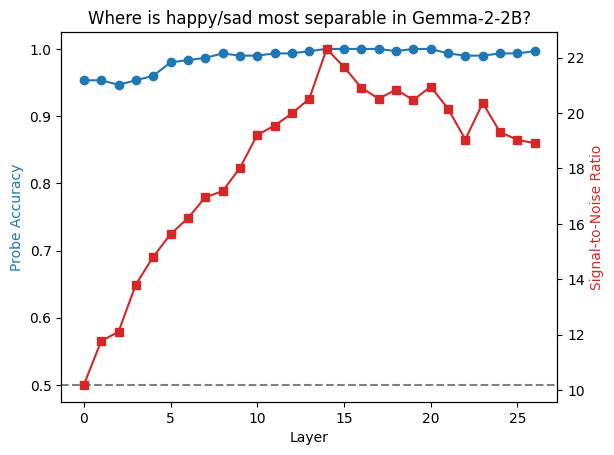

In [ ]:
import matplotlib.pyplot as plt

layers = [r["layer"] for r in layer_results]
accs = [r["probe_accuracy"] for r in layer_results]
snrs = [r["signal_to_noise"] for r in layer_results]

fig, ax1 = plt.subplots()
ax1.plot(layers, accs, marker='o', color='tab:blue', label='Probe Accuracy')
ax1.set_xlabel("Layer")
ax1.set_ylabel("Probe Accuracy", color='tab:blue')
ax1.axhline(0.5, color='gray', linestyle='--')

ax2 = ax1.twinx()
ax2.plot(layers, snrs, marker='s', color='tab:red', label='Signal-to-Noise')
ax2.set_ylabel("Signal-to-Noise Ratio", color='tab:red')

plt.title("Where is happy/sad most separable in Gemma-2-2B?")
plt.show()

In [ ]:
TARGET_LAYER = 14

happy_acts_l = all_activations[all_labels == 1, TARGET_LAYER, :]
sad_acts_l = all_activations[all_labels == 0, TARGET_LAYER, :]

steering_vector = happy_acts_l.mean(axis=0) - sad_acts_l.mean(axis=0)

# normalize to unit vector so "strength" means the same thing regardless of layer/scale
steering_vector = steering_vector / np.linalg.norm(steering_vector)

steering_vector = torch.tensor(steering_vector, dtype=torch.bfloat16).to(gemma.device)
print(steering_vector.shape)  # should be [hidden_dim]

torch.Size([2304])


In [ ]:
print(model)

In [ ]:
model.model.layers[14]

Gemma2DecoderLayer(
  (self_attn): Gemma2Attention(
    (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
    (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
  )
  (mlp): Gemma2MLP(
    (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
    (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
    (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
    (act_fn): GELUTanh()
  )
  (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
  (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
  (pre_feedforward_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
  (post_feedforward_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
)

In [ ]:
steering_hook_handle = None

def make_steering_hook(vector, strength):
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden = output[0]
            hidden = hidden + strength * vector
            return (hidden,) + output[1:]
        else:
            return output + strength * vector
    return hook

def add_steering_hook(strength, layer_idx=TARGET_LAYER, vector=steering_vector):
    global steering_hook_handle
    layer_module = gemma.model.layers[layer_idx]
    steering_hook_handle = layer_module.register_forward_hook(
        make_steering_hook(vector, strength)
    )

def remove_steering_hook():
    global steering_hook_handle
    if steering_hook_handle is not None:
        steering_hook_handle.remove()
        steering_hook_handle = None

In [ ]:
test_prompt = "Describe a walk in the park."

def run_prompt(prompt, max_new_tokens=50):
    inputs = tokenizer(prompt, return_tensors="pt").to(gemma.device)
    outputs = gemma.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, top_k=50, top_p=0.95)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

for strength in [0, -4, -8, 12, 16, -8, -16]:
    if strength != 0:
        add_steering_hook(strength)
    print(f"\n--- strength={strength} ---")
    print(run_prompt(test_prompt, max_new_tokens=60))
    remove_steering_hook()


--- strength=0 ---
Describe a walk in the park.

The sun was warm on my face as I walked through the bustling park. The air was alive with the chatter of children playing, the rustling of leaves, and the distant trilling of birds. It was a perfect spring day. 

I ventured down a shaded path, the mossy ground tick

--- strength=-4 ---
Describe a walk in the park.

The air hung heavy with the sweet scent of honeysuckle, a vibrant pink curtain swaying gently in the breeze. Sunlight filtered through the leafy canopy, dappling the path I walked with fleeting patches of light.  Birds chirped melodies from the vibrant branches of oak and maple trees, while squirrels chat

--- strength=-8 ---
Describe a walk in the park.

The sun was a mischievous child, throwing playful shadows across the paved path as I strolled through the park.  Trees stood like guardians, their leaves painted in hues of emerald and gold, whispering secrets to the wind.  A lazy breeze carried the scent of freshly cut gras

In [ ]:
vector_list = steering_vector.float().cpu().numpy().tolist()

# print as a plain comma-separated string you can copy into a text box
print(",".join([str(v) for v in vector_list]))

0.023193359375,0.033935546875,-0.0400390625,0.0159912109375,-0.004608154296875,0.000537872314453125,0.0181884765625,0.004669189453125,0.003326416015625,-0.0030670166015625,-0.00023555755615234375,0.008544921875,0.00106048583984375,0.0103759765625,-0.0034027099609375,0.031494140625,0.0184326171875,0.020263671875,-0.042236328125,-9.5367431640625e-05,-0.01068115234375,0.00506591796875,-0.0299072265625,-0.014892578125,0.00885009765625,0.00860595703125,-0.005096435546875,-0.0166015625,-0.00836181640625,-0.0264892578125,0.0306396484375,0.00537109375,0.0281982421875,0.0118408203125,0.0306396484375,-0.016845703125,0.00341796875,-0.0087890625,-0.0286865234375,0.01422119140625,-0.01239013671875,-0.004180908203125,0.0038909912109375,-0.0118408203125,0.000263214111328125,-0.003509521484375,-0.020263671875,0.01519775390625,0.00360107421875,-0.01556396484375,-0.01226806640625,-0.0111083984375,0.0079345703125,0.0634765625,-0.030029296875,-0.031982421875,-0.016845703125,0.0198974609375,-0.02734375,0.0

In [ ]:
TARGET_LAYER = 17 # Value from cell xpyzCq2QvYk7
steering_vector_dim = 1152 # Derived from steering_vector.shape in xpyzCq2QvYk7
STEER_STRENGTH = -16 # Using an example strength from the sweep in fzaXubhfvqEa
test_prompt = "Tell me about your day." # Value from cell fzaXubhfvqEa

print("Layer:", TARGET_LAYER - 1)   # adjusted for the embedding-layer offset
print("Vector dimension:", steering_vector_dim)
print("Strength used in my sweep:", STEER_STRENGTH)
print("Test prompt:", test_prompt)

Layer: 16
Vector dimension: 1152
Strength used in my sweep: -16
Test prompt: Tell me about your day.
